# Prolific Reading-QA Pilot (Three) — 3 reading conditions

Conditions: `birds`, `birds_repeat`, `birds_three`. 5 respondents per cell.

In [1]:
import csv
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from matplotlib.colors import ListedColormap

HERE = Path.cwd()
CSV_PATH = HERE / 'Prolific Reading-QA Pilot (Three)_June 5, 2026_15.13.csv'
YAML_PATH = HERE / 'birds_q.yaml'
TAG = 'three'

QIDS = [f'Q{n:02d}' for n in range(1, 11)]
LETTERS = ['A', 'B', 'C', 'D', 'E']
CONDS = ['birds', 'birds_repeat', 'birds_three']
COND_COLORS = {'birds': '#1f77b4', 'birds_repeat': '#ff7f0e', 'birds_three': '#2ca02c'}

In [ ]:
qdata = yaml.safe_load(YAML_PATH.read_text())['questions']
by_id = {q['q_id']: q for q in qdata}

with CSV_PATH.open(newline='', encoding='utf-8-sig') as f:
    rows = list(csv.DictReader(f))

ATTN_CHECKS = {'AT1': 'Gold versus green', 'AT2': 'Plumage strategy'}

def passed_attention(r):
    return all(r.get(k, '').strip() == v for k, v in ATTN_CHECKS.items())

finished_rows = [r for r in rows[2:] if r.get('Finished', '').lower() in {'true', '1'}]
failed_rows = [r for r in finished_rows if not passed_attention(r)]
data_rows = [r for r in finished_rows if passed_attention(r)]
by_cond = {c: [r for r in data_rows if r.get('assigned_doc') == c] for c in CONDS}
print('Finished respondents:', len(finished_rows))
print('Failed attention checks (excluded):', len(failed_rows))
print('Retained respondents:', len(data_rows))
for c in CONDS:
    print(f'  {c}: {len(by_cond[c])}')

def edges(qid):
    return by_id[qid].get('metadata', {}).get('tags', {}).get('edges', 0) or 0

# Sort by question number (Q01 … Q10)
SORTED_QIDS = QIDS

In [ ]:
def resp_letters(r, qid):
    """Return frozenset of selected letters for a question (handles single and multi-select)."""
    opts = by_id[qid]['options']
    text_to_letter = {v.strip(): k for k, v in opts.items()}
    val = r.get(qid, '').strip()
    if not val:
        return frozenset()
    # Qualtrics stores multi-select as comma-separated letters or option texts.
    parts = [p.strip() for p in val.split(',')]
    result = set()
    for p in parts:
        if p in LETTERS:
            result.add(p)
        elif p in text_to_letter:
            result.add(text_to_letter[p])
        else:
            m = next((k for k, v in opts.items() if v.strip().split() == p.split()), None)
            if m:
                result.add(m)
    return frozenset(result)

def correct_set(qid):
    """Return frozenset of correct letters for a question."""
    ans = by_id[qid]['answer']
    if isinstance(ans, list):
        return frozenset(ans)
    return frozenset([ans])

def is_correct(r, qid):
    """Exact-match: participant must select exactly the right set of letters."""
    return resp_letters(r, qid) == correct_set(qid)

def correctness_matrix(rows_):
    M = np.zeros((len(rows_), len(SORTED_QIDS)), dtype=int)
    for i, r in enumerate(rows_):
        for j, qid in enumerate(SORTED_QIDS):
            M[i, j] = 1 if is_correct(r, qid) else 0
    return M

Ms = {c: correctness_matrix(by_cond[c]) for c in CONDS}

# Sanity check: print correct sets for multi-select questions
for qid in SORTED_QIDS:
    ans = by_id[qid]['answer']
    if isinstance(ans, list):
        print(f'{qid} multi-select correct={ans}')

## Per-question accuracy by condition (grouped bars)

In [ ]:
RNG = np.random.default_rng(42)
N_BOOT = 2000

def bootstrap_ci(arr, n_boot=N_BOOT, ci=95):
    """Return (lo, hi) bootstrap CI for the mean of a 1-D binary array."""
    if len(arr) == 0:
        return (0.0, 0.0)
    boots = RNG.choice(arr, size=(n_boot, len(arr)), replace=True).mean(axis=1)
    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    return (lo, hi)

def q_label(qid):
    ans = by_id[qid]['answer']
    return f'{qid}{"*" if isinstance(ans, list) else ""}'

ordered_qids = SORTED_QIDS

fig, (ax_q, ax_s) = plt.subplots(1, 2, figsize=(16, 5),
                                   gridspec_kw={'width_ratios': [3, 1]})

# ── Left: per-question accuracy with bootstrap CIs ──────────────────────────
x = np.arange(len(ordered_qids))
w = 0.27
for k, c in enumerate(CONDS):
    M = Ms[c]
    if len(M) == 0:
        continue
    accs = M.mean(axis=0)
    errs_lo, errs_hi = [], []
    for j in range(len(SORTED_QIDS)):
        lo, hi = bootstrap_ci(M[:, j])
        errs_lo.append(accs[j] - lo)
        errs_hi.append(hi - accs[j])
    xpos = x + (k - 1) * w
    ax_q.bar(xpos, accs, w, color=COND_COLORS[c], label=f'{c} (n={len(by_cond[c])})')
    ax_q.errorbar(xpos, accs, yerr=[errs_lo, errs_hi],
                  fmt='none', color='black', capsize=3, linewidth=1)
    for i, a in enumerate(accs):
        ax_q.text(xpos[i], a + errs_hi[i] + 0.03, f'{a:.0%}', ha='center', fontsize=6)

ax_q.axhline(0.20, color='red', ls='--', label='chance (1/5)')
ax_q.set_xticks(x)
ax_q.set_xticklabels([q_label(q) for q in ordered_qids])
ax_q.set_ylim(0, 1.15)
ax_q.set_ylabel('Accuracy')
ax_q.set_xlabel('Question (* = multi-select)')
ax_q.set_title('Per-question accuracy by condition\n(error bars = 95% bootstrap CI)')
ax_q.legend(fontsize=8)

# ── Right: score distribution (overlapping histograms) ───────────────────────
bins = np.arange(-0.5, len(SORTED_QIDS) + 1.5, 1)  # integer-centered 0–10
for c in CONDS:
    M = Ms[c]
    if len(M) == 0:
        continue
    person_scores = M.sum(axis=1)
    mean_s = person_scores.mean()
    ax_s.hist(person_scores, bins=bins, alpha=0.55, color=COND_COLORS[c],
              label=f'{c} (mean={mean_s:.1f})', edgecolor='white', linewidth=0.5)
    ax_s.axvline(mean_s, color=COND_COLORS[c], ls='--', lw=1.5)

ax_s.set_xticks(np.arange(0, len(SORTED_QIDS) + 1))
ax_s.set_xlabel('Score (correct out of 10)')
ax_s.set_ylabel('Count')
ax_s.set_title('Score distribution\nper condition')
ax_s.legend(fontsize=7)

plt.tight_layout()
fig.savefig(f'per_question_accuracy_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-respondent accuracy (colored by condition)

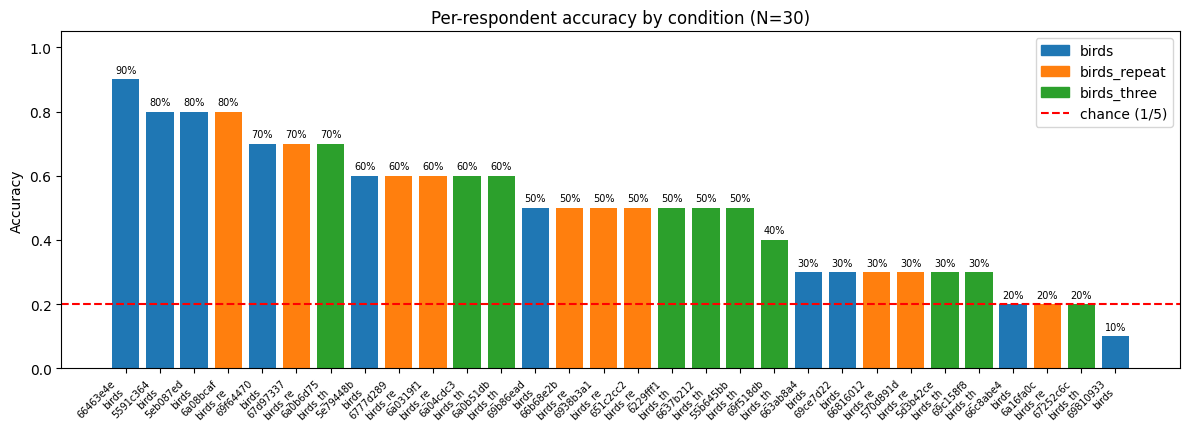

In [5]:
rows_flat, colors_flat, pids_flat, accs_flat = [], [], [], []
for c in CONDS:
    for i, r in enumerate(by_cond[c]):
        acc = Ms[c][i].mean()
        pid = (r.get('PROLIFIC_PID') or f'R{i}')[:8]
        rows_flat.append((c, pid, acc))
rows_flat.sort(key=lambda x: (-x[2], x[0]))
labels = [f'{p}\n{c[:8]}' for c, p, _ in rows_flat]
vals = [a for _, _, a in rows_flat]
bar_colors = [COND_COLORS[c] for c, _, _ in rows_flat]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(range(len(vals)), vals, color=bar_colors)
ax.axhline(0.20, color='red', ls='--', label='chance (1/5)')
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title(f'Per-respondent accuracy by condition (N={len(vals)})')
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=7)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=COND_COLORS[c], label=c) for c in CONDS] +
         [plt.Line2D([0], [0], color='red', ls='--', label='chance (1/5)')])
plt.tight_layout()
fig.savefig(f'per_respondent_accuracy_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

## Correctness grids per condition (rows=respondents sorted by accuracy, cols=questions sorted by accuracy desc within each condition)

In [ ]:
cmap = ListedColormap(['#f0f0f0', '#2ca02c'])
fig, axes = plt.subplots(len(CONDS), 1, figsize=(12, 2 + 1.2 * len(CONDS) * max(len(Ms[c]) for c in CONDS) * 0.35))
if len(CONDS) == 1:
    axes = [axes]

# Columns in Q number order
grid_qids = SORTED_QIDS
col_order = np.arange(len(SORTED_QIDS))

for ax, c in zip(axes, CONDS):
    M = Ms[c]
    if len(M) == 0:
        ax.set_visible(False); continue
    person_acc = M.mean(axis=1)
    row_order = np.argsort(-person_acc)
    M_s = M[row_order]
    pids = [(by_cond[c][i].get('PROLIFIC_PID') or f'R{i}')[:8] for i in row_order]
    pacc = person_acc[row_order]
    cond_q_acc = M.mean(axis=0)
    ax.imshow(M_s, aspect='auto', cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(grid_qids)))
    ax.set_xticklabels([f'{q_label(q)}\n({a:.0%})' for q, a in zip(grid_qids, cond_q_acc)], fontsize=7)
    ax.set_yticks(range(len(pids)))
    ax.set_yticklabels([f'{p} ({a:.0%})' for p, a in zip(pids, pacc)], fontsize=7)
    ax.set_title(f'{c}  (n={len(M)}, mean acc={M.mean():.0%})')
    ax.set_xticks(np.arange(-0.5, len(grid_qids), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(pids), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.tick_params(which='minor', length=0)
plt.tight_layout()
fig.savefig(f'correctness_grid_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

## Answer distribution per question, split by condition

In [ ]:
def tally_multi(rows_, qid):
    """Count how many respondents selected each letter (multi-select aware)."""
    counts = Counter({L: 0 for L in LETTERS})
    for r in rows_:
        for L in resp_letters(r, qid):
            counts[L] += 1
    return counts

fig, axes = plt.subplots(5, 2, figsize=(16, 26))
axes = axes.flatten()
for ax, qid in zip(axes, SORTED_QIDS):
    correct = by_id[qid]['answer']
    correct_s = correct_set(qid)
    x = np.arange(len(LETTERS))
    w = 0.27
    for k, c in enumerate(CONDS):
        counts = tally_multi(by_cond[c], qid)
        vals = [counts[L] for L in LETTERS]
        edgecols = ['black' if L in correct_s else 'none' for L in LETTERS]
        ax.bar(x + (k - 1) * w, vals, w, color=COND_COLORS[c],
               edgecolor=edgecols, linewidth=1.5,
               label=c if qid == SORTED_QIDS[0] else None)
    ax.set_xticks(x)
    ax.set_xticklabels(LETTERS)
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(len(by_cond[c]) for c in CONDS))
    q = by_id[qid]
    ax.set_title(f'{q_label(qid)} (correct: {correct})\n{q["question"][:90]}', fontsize=8, loc='left')
axes[0].legend(loc='upper right', fontsize=8)
plt.tight_layout()
fig.savefig(f'answer_distributions_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show()